**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

**Data Loading**

In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**EDA**

In [ ]:
df.shape

(891, 15)

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


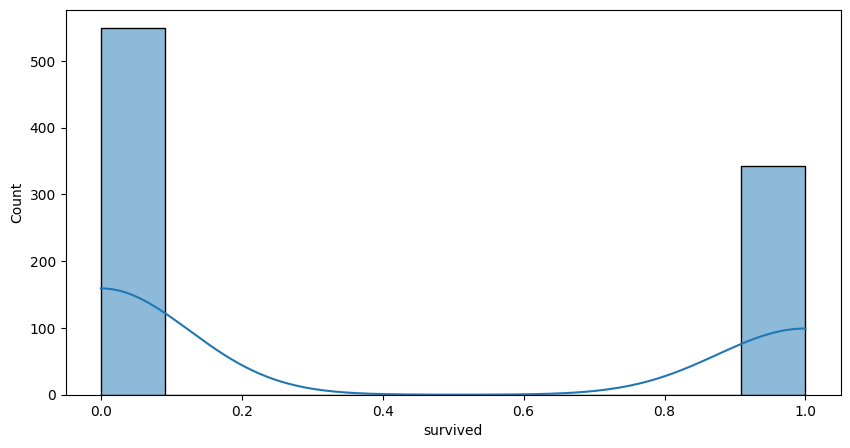

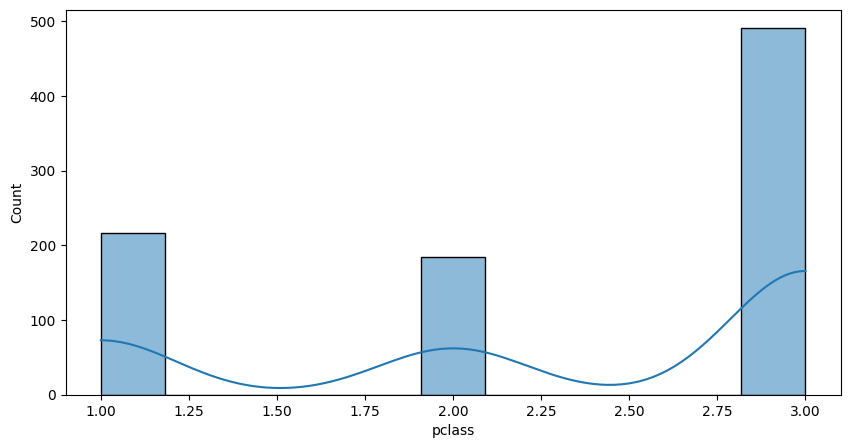

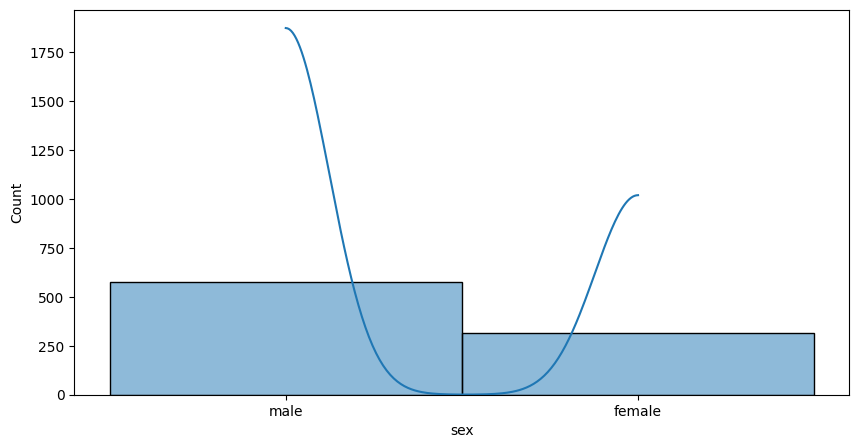

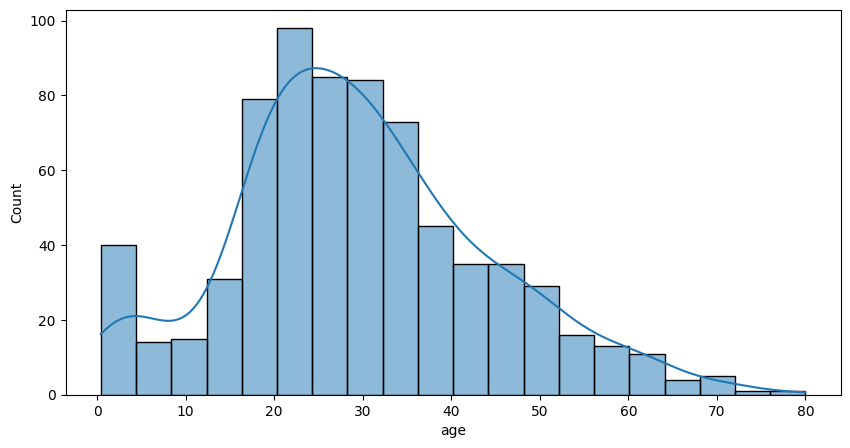

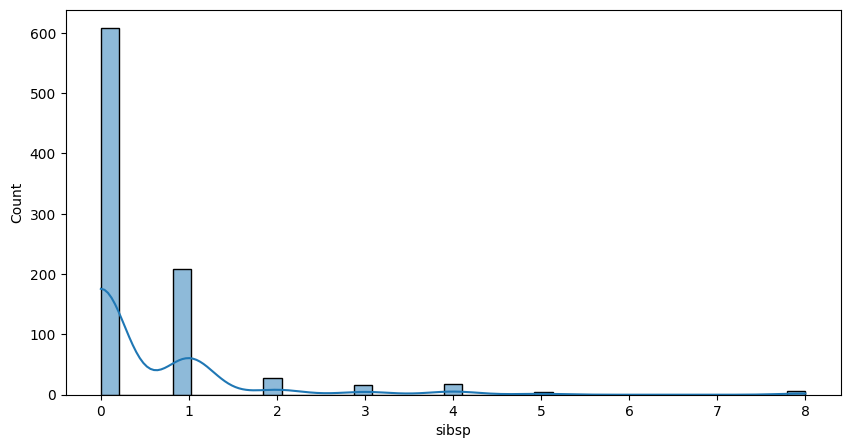

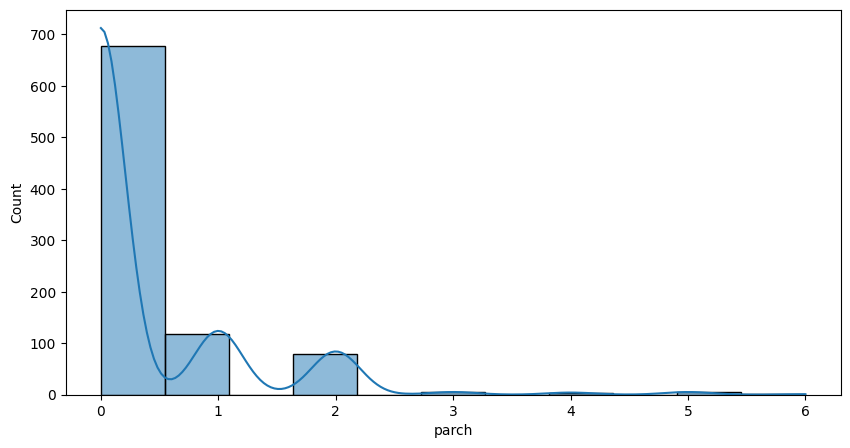

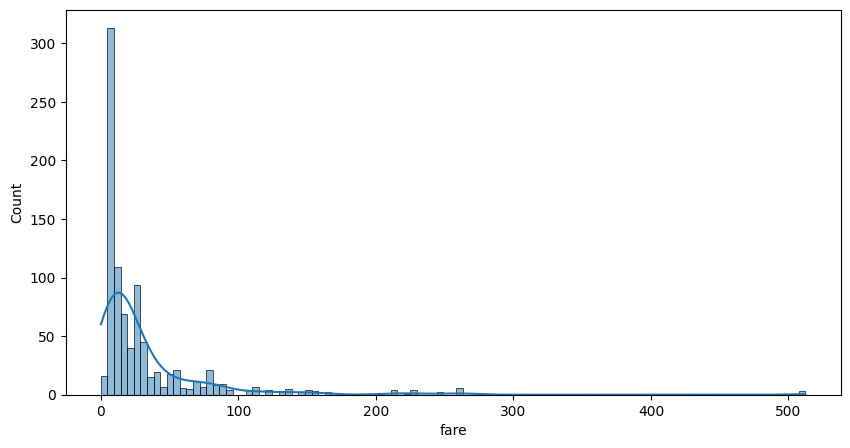

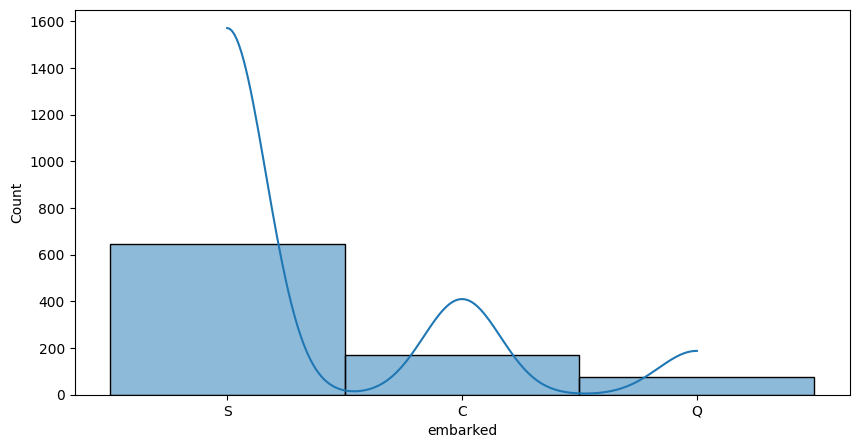

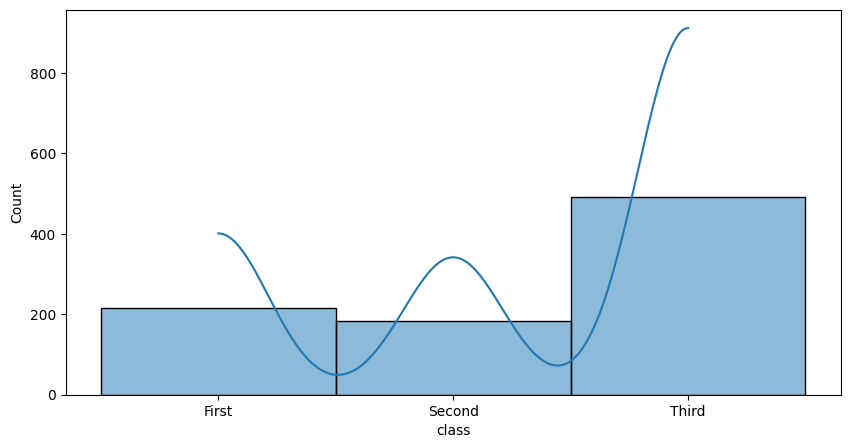

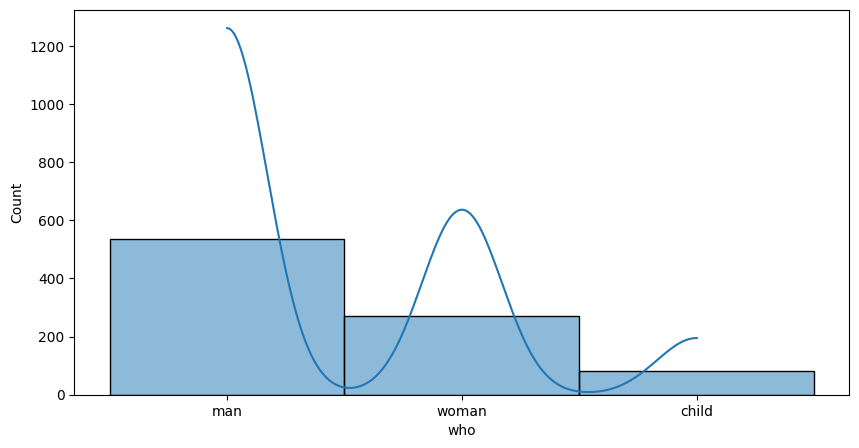

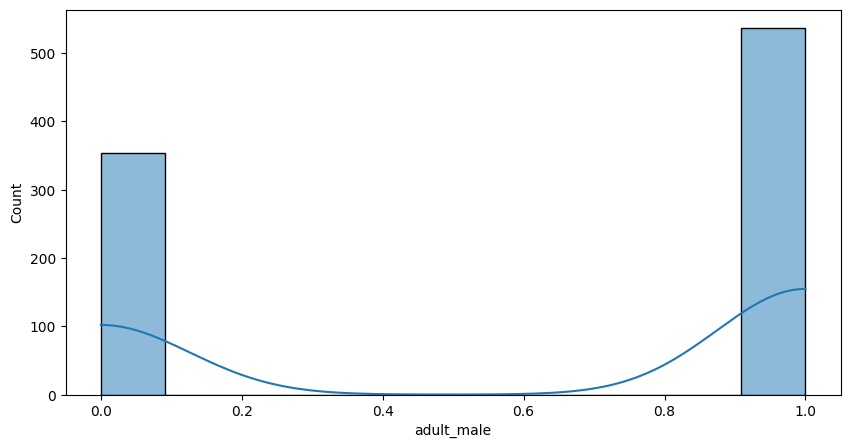

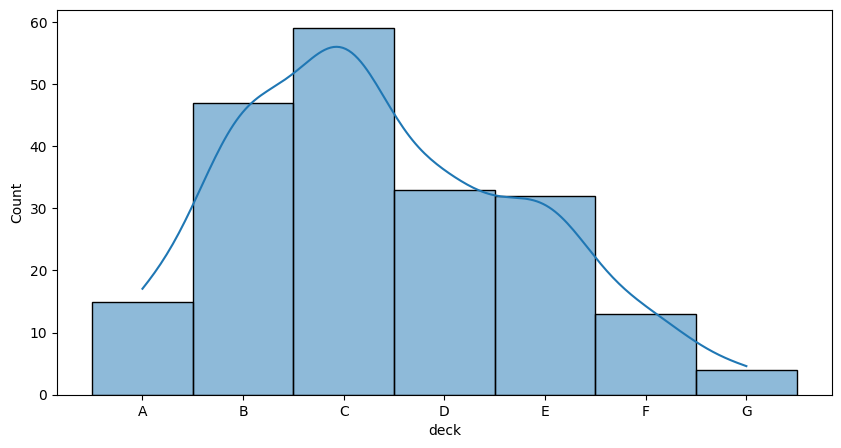

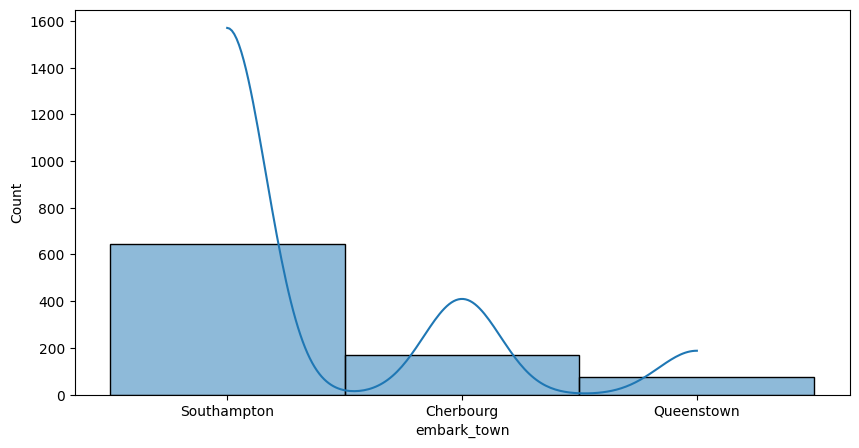

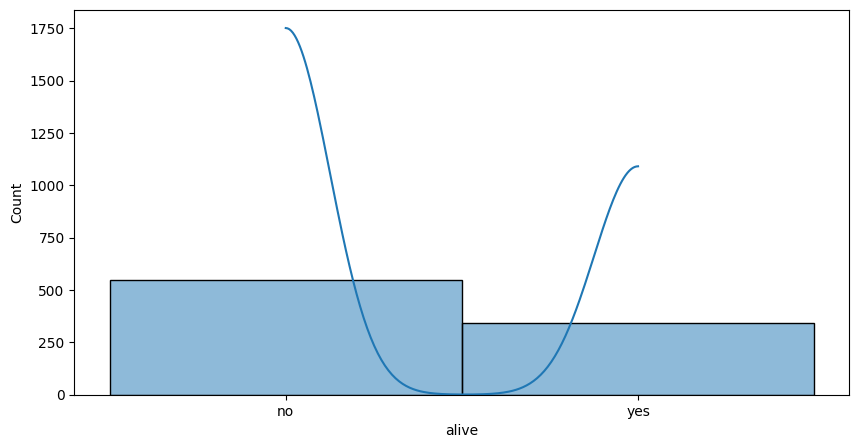

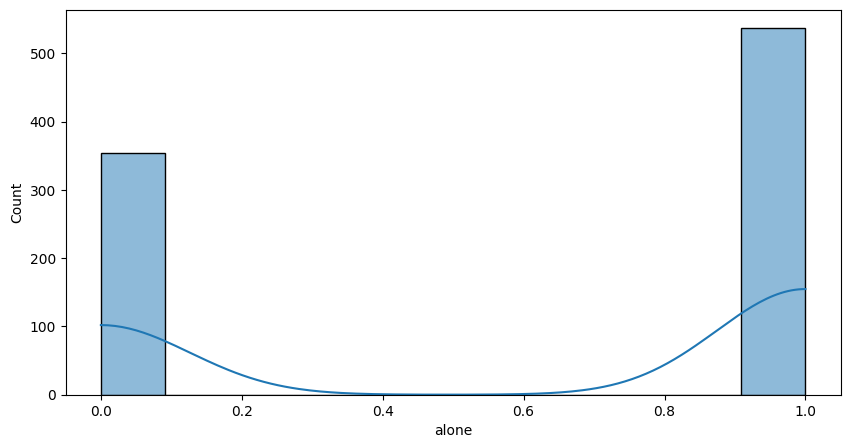

In [ ]:
for col in df.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col], kde=True)
    plt.show()

<Axes: >

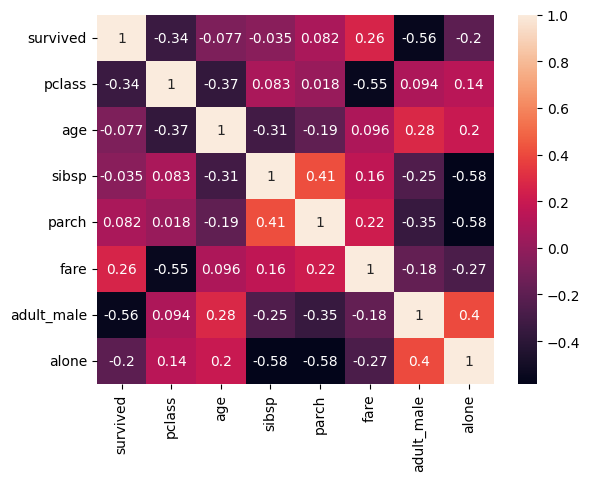

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

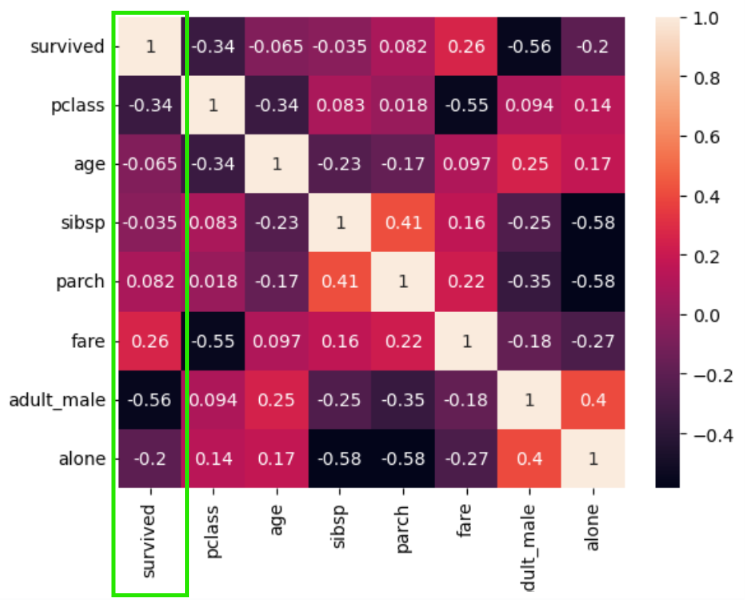

**Data Cleaning**

In [ ]:
df.drop(columns=['deck', 'who', 'alive','alone'], inplace=True)

In [ ]:
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace=True)

In [ ]:
# as distribution is right skewed so use median

df['age'].fillna(df['age'].median(), inplace = True)

In [ ]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
adult_male,0


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton


**Separating Input & Target Variables**

In [ ]:
X = df.drop(columns=['survived'])
y = df['survived']

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town
0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton
1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg
2,3,female,26.0,0,0,7.9250,S,Third,False,Southampton
3,1,female,35.0,1,0,53.1000,S,First,False,Southampton
4,3,male,35.0,0,0,8.0500,S,Third,True,Southampton


In [ ]:
from scipy.stats import pearsonr

numeric_cols = X.select_dtypes(include=['number']).columns

for col in numeric_cols:
    corr, _ = pearsonr(X[col], y)
    print(f"Pearson correlation for {col}: {corr:.3f}")

Pearson correlation for pclass: -0.338
Pearson correlation for age: -0.065
Pearson correlation for sibsp: -0.035
Pearson correlation for parch: 0.082
Pearson correlation for fare: 0.257


In [ ]:
from scipy.stats import chi2_contingency

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

alpha = 0.05
chi2_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(X[col], y)

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)



    if p_value <= alpha:
        decision = "Reject H0 (Keep Feature - Significant)"
    else:
        decision = "Fail to Reject H0 (Drop Feature - Not Significant)"

    chi2_results.append({
        "Feature": col,
        "Chi-Square": chi2.round(5),
        "P-value": p_value.round(5),
        "Decision": decision
    })
chi2_score_data = pd.DataFrame(chi2_results)
chi2_score_data


,Feature,Chi-Square,P-value,Decision
0,sex,260.71702,0.0,Reject H0 (Keep Feature - Significant)
1,embarked,26.48915,0.0,Reject H0 (Keep Feature - Significant)
2,class,102.88899,0.0,Reject H0 (Keep Feature - Significant)
3,embark_town,25.96445,0.0,Reject H0 (Keep Feature - Significant)


**One Hot Encoding**

In [ ]:
X['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

In [ ]:
X = pd.get_dummies(X, columns=['embark_town'], prefix='embark_town')

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3,male,22.0,1,0,7.2500,S,Third,True,False,False,True
1,1,female,38.0,1,0,71.2833,C,First,False,True,False,False
2,3,female,26.0,0,0,7.9250,S,Third,False,False,False,True
3,1,female,35.0,1,0,53.1000,S,First,False,False,False,True
4,3,male,35.0,0,0,8.0500,S,Third,True,False,False,True


**Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['sex', 'embarked','class']:
    X[col] = le.fit_transform(X[col])

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3,1,22.0,1,0,7.2500,2,2,True,False,False,True
1,1,0,38.0,1,0,71.2833,0,0,False,True,False,False
2,3,0,26.0,0,0,7.9250,2,2,False,False,False,True
3,1,0,35.0,1,0,53.1000,2,0,False,False,False,True
4,3,1,35.0,0,0,8.0500,2,2,True,False,False,True


**Standard Scalling**

In [ ]:
X_scaled = X.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_scaled[['sex', 'fare']] = scaler.fit_transform(X_scaled[['sex', 'fare']])

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3,1,22.0,1,0,7.2500,2,2,True,False,False,True
1,1,0,38.0,1,0,71.2833,0,0,False,True,False,False
2,3,0,26.0,0,0,7.9250,2,2,False,False,False,True
3,1,0,35.0,1,0,53.1000,2,0,False,False,False,True
4,3,1,35.0,0,0,8.0500,2,2,True,False,False,True


In [ ]:
X_scaled = X_scaled.astype(float)

In [ ]:
X_scaled.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3.0,0.737695,22.0,1.0,0.0,-0.502445,2.0,2.0,1.0,0.0,0.0,1.0
1,1.0,-1.355574,38.0,1.0,0.0,0.786845,0.0,0.0,0.0,1.0,0.0,0.0
2,3.0,-1.355574,26.0,0.0,0.0,-0.488854,2.0,2.0,0.0,0.0,0.0,1.0
3,1.0,-1.355574,35.0,1.0,0.0,0.420730,2.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.737695,35.0,0.0,0.0,-0.486337,2.0,2.0,1.0,0.0,0.0,1.0


**Train Test Split**

Some algorithms require scaling, while others do not. **Distance or weight-based algorithms** like KNN can be affected by different feature ranges, **requires scaling**. For example, a feature ranging from 0–3 can have less influence than age ranging from 14–100, affecting predictions.

***Footnote:** Tree-based algorithms generally do not require scaling.*


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled, X_test_scaled, _, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# **Logistic Regression Model Training**

*Do not requres the scaled features.*

In [ ]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression()


model_LR.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred_LR = model_LR.predict(X_test)

In [ ]:
y_pred_LR

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [ ]:
y_test

,survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


**Model Evaluation**

Sabse important:

	- FN dangerous → Recall
	- FP dangerous → Precision
	- FP + FN both dangerous → F1
	- Balanced classes + overall correctness → Accuracy
Agar tum classification dataset dekh kar sirf 10 seconds mein metric choose karna chahte ho, toh bas yeh poochna:
**"Meri sabse dangerous mistake FP hai ya FN?"**




```
[[TN, FP],
 [FN, TP]]
```

> So in this case if a person survived and considered as dead is dangerous means **FN** so we have to maximize the **Recall**





---


Sabse pehle: **"Model ne bola" vs "Actual mein tha"**

Confusion Matrix mein 2 sides hoti hain:

	• Model ne kya bola? → Prediction
	• Actually kya tha? → Reality
Aur **True/False** batata hai **prediction correct tha ya wrong**.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


accuracy_score(y_test, y_pred_LR)

0.7988826815642458

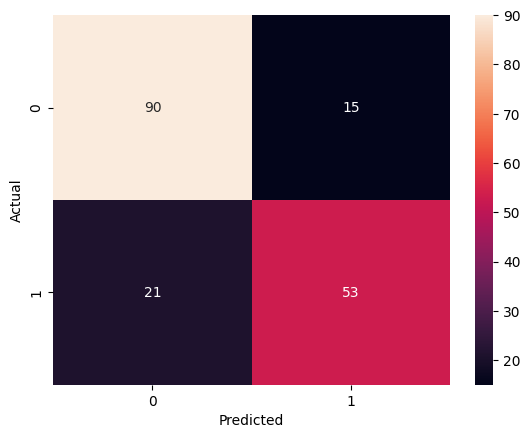

In [ ]:
cm = confusion_matrix(y_test, y_pred_LR)


sns.heatmap(cm,fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



**Overfitting & Underfitting in Classification Models**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Training predictions
y_train_pred = model_LR.predict(X_train)

# Test predictions
y_test_pred = model_LR.predict(X_test)

In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.8286516853932584
Test Accuracy: 0.7988826815642458


In [ ]:
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)


print("Train F1:", train_f1)
print("Test F1:", test_f1)

Train F1: 0.7607843137254902
Test F1: 0.7464788732394366


> **Note: Resolving Target Data Leakage**
> Previously, classifiers achieved an artificial accuracy score of **1.00** due to data leakage caused by the `alive` column, which acts as a direct proxy for the target variable `survived`. To ensure realistic training and unbiased evaluation, `alive` was removed alongside `survived` (`X = df.drop(columns=['survived', 'alive'])`). This forces the models to learn genuine patterns from true independent features.

# **KNN Classifier**


**1. Define $k$ value** (e.g., $k = 5$)

**2. Calculate (Euclidean) distance** from the query point to all training points

**3. Sort all distances** in ascending order

**4. Select the top $k$** nearest points (smallest distances)

* **Categorical (Classification):**
Check the majority class count among $k$ neighbors and classify into that class.
* **Continuous (Regression):**
Calculate the mean (average) of the target values for the $k$ selected points.

---

**Note:** It requres feature scaling to match the scale of all features.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN = KNeighborsClassifier(n_neighbors=15)
model_KNN.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=15)

In [ ]:
y_pred_KNN = model_KNN.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred_KNN))
print("Accuracy:", accuracy_score(y_test, y_pred_KNN))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       105
           1       0.86      0.69      0.77        74

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

Accuracy: 0.8268156424581006


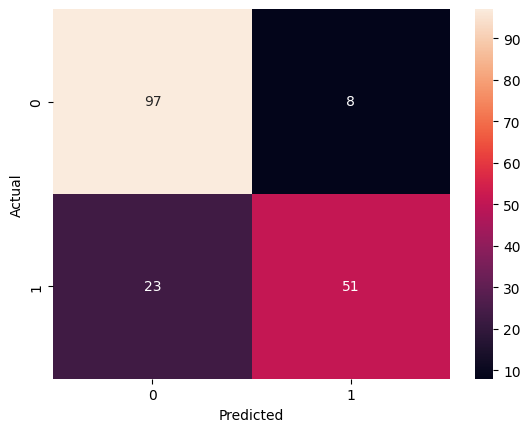

In [ ]:
cm = confusion_matrix(y_test, y_pred_KNN)


sns.heatmap(cm,fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


> Model accuracy varies when tuning the `n_neighbors` hyperparameter (e.g., `n_neighbors=15`). It is **recommended to keep $k$ (`n_neighbors`) as an odd number** to ensure a clear majority vote and prevent ties that can occur with even numbers.


**For this case k = 15 turns out to be best value.**

### **Navie Bayes**

# Naive Bayes

## 1. Independent Events

When two events are **independent**, the occurrence of one does not affect the other.

### Coin

$$
P(H)=\frac{1}{2}, \qquad P(T)=\frac{1}{2}
$$

### Dice

$$
P(6)=\frac{1}{6}, \qquad P(4)=\frac{1}{6}
$$

For independent events:

$$
P(A \cap B)=P(A)\times P(B)
$$

Example:

$$
P(H \text{ and } T)
=
P(H)\times P(T)
=
\frac{1}{2}\times\frac{1}{2}
=
\frac{1}{4}
$$

Possible outcomes of two coin tosses:

- HH
- HT
- TH
- TT

---

## 2. Dependent Events

When the occurrence of one event **affects the probability of another event**, the events are dependent.

### Example: Deck of Cards

A deck contains:

$$
52 \text{ cards}
$$

- 26 Red cards
- 26 Black cards

Initially:

$$
P(R)=\frac{26}{52}=\frac{1}{2}
$$

If one red card is already drawn, only **51 cards remain**, with 25 red cards:

$$
P(R)=\frac{25}{51}
$$

So, the probability changed because the first event affected the second event.

For dependent events:

$$
P(A \cap B)=P(A)\times P(B|A)
$$

Where:

- $P(B|A)$ = Probability of B **given that A has occurred**

---

# 3. Bayes' Theorem

We know:

$$
P(A \cap B)=P(B \cap A)
$$

Therefore:

$$
P(A)\times P(B|A)
=
P(B)\times P(A|B)
$$

Rearranging:

$$
\boxed{
P(A|B)=\frac{P(A)\times P(B|A)}{P(B)}
}
$$

This is **Bayes' Theorem**.

---

# 4. Naive Bayes in Machine Learning

Suppose:

- $x_1,x_2,x_3,x_4$ = independent features
- $y$ = dependent/target variable

For example:

$$
y =
\begin{cases}
0 & \text{No}\\
1 & \text{Yes}
\end{cases}
$$

Using Bayes' Theorem:

$$
P(y|x_1,x_2,x_3,x_4)
=
\frac{
P(y)\times P(x_1,x_2,x_3,x_4|y)
}{
P(x_1,x_2,x_3,x_4)
}
$$

### Naive Assumption

Naive Bayes assumes that the features are **conditionally independent given the class**.

Therefore:

$$
P(x_1,x_2,x_3,x_4|y)
=
P(x_1|y)
P(x_2|y)
P(x_3|y)
P(x_4|y)
$$

So:

$$
P(y|x_1,x_2,x_3,x_4)
=
\frac{
P(y)
P(x_1|y)
P(x_2|y)
P(x_3|y)
P(x_4|y)
}{
P(x_1,x_2,x_3,x_4)
}
$$

For classification, we calculate the probability for each class.

### For $y=1$

$$
P(1|x_1,x_2,x_3,x_4)
\propto
P(1)
P(x_1|1)
P(x_2|1)
P(x_3|1)
P(x_4|1)
$$

### For $y=0$

$$
P(0|x_1,x_2,x_3,x_4)
\propto
P(0)
P(x_1|0)
P(x_2|0)
P(x_3|0)
P(x_4|0)
$$

The class with the **higher probability** becomes the prediction.

### Naive Bayes Variants

- **GaussianNB** → Continuous numerical data; assumes features are approximately normally distributed.
- **MultinomialNB** → Count/frequency data, mainly for text classification.
- **BernoulliNB** → Binary features (0/1), e.g. word present/absent.
- **CategoricalNB** → Categorical features, e.g. gender, color, size.

$$
\text{Numerical} \rightarrow \text{GaussianNB}
$$

$$
\text{Counts/Frequencies} \rightarrow \text{MultinomialNB}
$$

$$
\text{Binary} \rightarrow \text{BernoulliNB}
$$

$$
\text{Categorical} \rightarrow \text{CategoricalNB}
$$

---

**Note:**
- It do not requires feature scaling.
- Why GaussianNB?
  - Bcuz GaussianNB refers to **Gaussian Distirbution** $\rightarrow$ **Normal Distribution**


In [ ]:
from sklearn.naive_bayes import GaussianNB

model_NB = GaussianNB()
model_NB.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_NB = model_NB.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred_NB))
print("Accuracy:", accuracy_score(y_test, y_pred_NB))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       105
           1       0.70      0.77      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.77      0.77      0.77       179

Accuracy: 0.7653631284916201


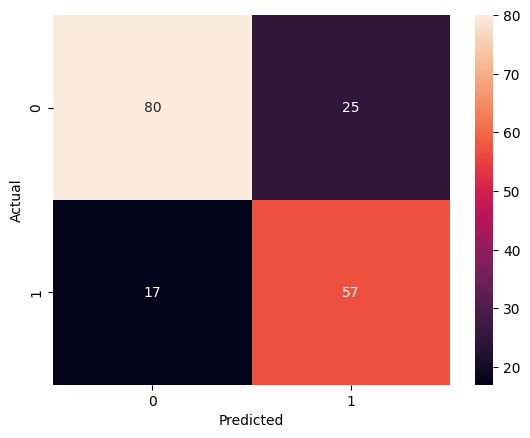

In [ ]:
cm = confusion_matrix(y_test, y_pred_NB)


sns.heatmap(cm,fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Decision Tree**

# Decision Tree

A **Decision Tree** is a supervised learning algorithm used for both **classification and regression**.

## How a Decision Tree Works

1. Start with the complete dataset.
2. Choose the **best feature** for splitting the data.
3. Create branches based on the feature's values.
4. Repeat the process for each branch.
5. Stop when a suitable stopping condition is reached.

---

## Entropy

Entropy measures the **impurity/uncertainty** in a dataset.

$$
Entropy(S)
=
-P_{+}\log_2(P_{+})
-
P_{-}\log_2(P_{-})
$$

For the `Play` dataset:

$$
Entropy(S)
=
-\frac{9}{14}\log_2\left(\frac{9}{14}\right)
-
\frac{5}{14}\log_2\left(\frac{5}{14}\right)
$$

$$
\approx 0.940
$$

- Entropy = **0** → Pure data
- Higher entropy → More mixed/uncertain data

---

## Information Gain

Information Gain tells us **how much uncertainty is reduced** after splitting on a feature.

$$
IG(S,A)
=
Entropy(S)
-
\sum_{v \in Values(A)}
\frac{|S_v|}{|S|}
Entropy(S_v)
$$

### Information Gain for Outlook

$$
IG(S,Outlook)
=
0.940
-
\left[
\frac{5}{14}(0.971)
+
\frac{4}{14}(0)
+
\frac{5}{14}(0.971)
\right]
$$

$$
\approx 0.246
$$

Similarly:

$$
IG(Outlook) \approx 0.246
$$

$$
IG(Temperature) \approx 0.029
$$

$$
IG(Humidity) \approx 0.151
$$

$$
IG(Wind) \approx 0.048
$$

Therefore:

$$
Outlook \rightarrow \text{Highest Information Gain}
$$

So **Outlook becomes the root node**.

---

## Decision Tree Splitting Rule

$$
\boxed{
\text{Choose the feature with the highest Information Gain}
}
$$

The process is repeated for each branch until a **stopping condition** is reached.

### Common Stopping Conditions

- Node becomes pure.
- No useful features remain.
- Maximum tree depth is reached.
- Minimum number of samples required for splitting is reached.

## Decision Tree Regression — MSE Example

---
### Continuous Features

Decision Trees can also handle **continuous numerical features** such as age, salary, temperature, etc.

Suppose we want to predict **Fare** using **Age**:

| Age | Fare |
|---:|---:|
| 20 | 10 |
| 22 | 12 |
| 25 | 15 |
| 30 | 20 |
| 35 | 35 |
| 40 | 40 |

The Decision Tree tries different thresholds, for example:

$$
Age \leq 32.5 \rightarrow Left
$$

$$
Age > 32.5 \rightarrow Right
$$

**Left group:** $10,12,15,20$

$$
\bar{y}_{left}
=
\frac{10+12+15+20}{4}
=
14.25
$$

$$
MSE_{left}
=
\frac{(10-14.25)^2+(12-14.25)^2+(15-14.25)^2+(20-14.25)^2}{4}
\approx 16.69
$$

**Right group:** $35,40$

$$
\bar{y}_{right}
=
\frac{35+40}{2}
=
37.5
$$

$$
MSE_{right}
=
\frac{(35-37.5)^2+(40-37.5)^2}{2}
=
6.25
$$

The tree tests different thresholds and chooses the split that gives the **lowest overall MSE**.

$$
\boxed{
\text{Best Split}
=
\text{Split with minimum MSE}
}
$$

For **classification**, the target is categorical (e.g. Yes/No), so we commonly use:

$$
\boxed{\text{Gini Impurity or Information Gain}}
$$

For **regression**, the target is continuous (e.g. Fare/Salary), so we commonly use:

$$
\boxed{\text{Mean Squared Error (MSE)}}
$$

---
**Note:** Requires the scaled data

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier()
model_DT.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_DT = model_DT.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred_DT))
print("Accuracy:", accuracy_score(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.81      0.76      0.78       105
           1       0.69      0.74      0.71        74

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.75      0.76       179

Accuracy: 0.7541899441340782


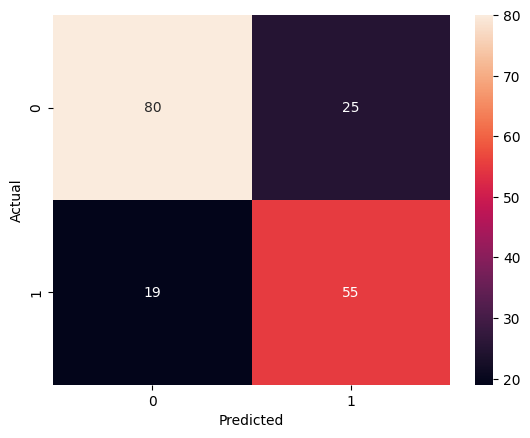

In [ ]:
cm = confusion_matrix(y_test, y_pred_DT)


sns.heatmap(cm,fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Support Vector Machine (SVM)

**SVM (Support Vector Machine)** is a supervised learning algorithm used for **classification and regression**. It tries to find the best boundary that separates different classes while maximizing the **margin**.

### Key Concepts

- **Hyperplane** → A decision boundary that separates classes.
- **Margin** → The distance between the hyperplane and the closest data points.
- **Support Vectors** → The closest data points to the hyperplane; they determine the position of the boundary.
- **Kernel** → A function that helps SVM handle non-linear relationships by mapping data into a higher-dimensional space.

For a linear SVM:

$$
w^Tx+b=0
$$

where:

$$
w = \text{weights}, \qquad b = \text{bias}
$$

Prediction:

$$
w^Tx+b>0 \rightarrow \text{Class 1}
$$

$$
w^Tx+b<0 \rightarrow \text{Class 2}
$$


---
### Common Kernels

$$
\text{Linear Kernel: } K(x_i,x_j)=x_i^Tx_j
$$

Useful when classes are approximately **linearly separable**.

$$
\text{Polynomial Kernel: } K(x_i,x_j)=(\gamma x_i^Tx_j+r)^d
$$

Useful for **polynomial/non-linear relationships**.

$$
\text{RBF Kernel: } K(x_i,x_j)=e^{-\gamma\|x_i-x_j\|^2}
$$

A popular default for **complex non-linear data**.

$$
\text{Sigmoid Kernel: } K(x_i,x_j)=\tanh(\gamma x_i^Tx_j+r)
$$

Can model certain **non-linear relationships**, but is less commonly used than RBF.

---

### Important

SVM is **sensitive to feature scale**, so scaling is usually required:

$$
X \rightarrow \text{StandardScaler} \rightarrow SVM
$$

For regression, SVM uses **SVR (Support Vector Regression)** instead of SVC.

In [ ]:
from sklearn.svm import SVC

model_SVC = SVC()

model_SVC.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred_SVC = model_SVC.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred_SVC))
print("Accuracy:", accuracy_score(y_test, y_pred_SVC))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Accuracy: 0.8044692737430168


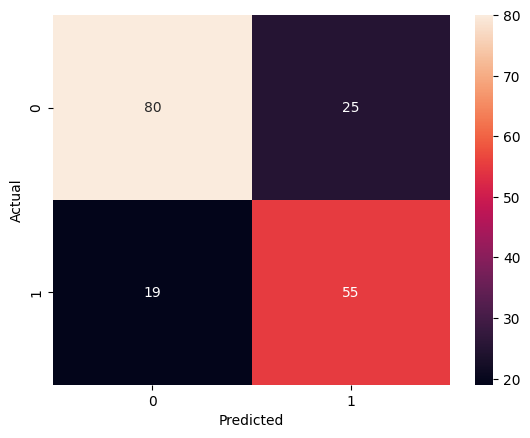

In [ ]:
cm = confusion_matrix(y_test, y_pred_DT)


sns.heatmap(cm,fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Comparison

In [ ]:
y_pred = [y_pred_LR, y_pred_KNN, y_pred_DT, y_pred_NB, y_pred_SVC]
name = ['Logistic Regression']



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

y_pred = [y_pred_LR, y_pred_KNN, y_pred_DT, y_pred_NB, y_pred_SVC]

name = ["Logistic Regression", "KNN", "Decision Tree", "Naive Bayes", "SVM"]


accuracy = []
for pred in y_pred:
    accuracy.append(accuracy_score(y_test, pred))

df = pd.DataFrame({"Model": name, "Accuracy": accuracy})
df

,Model,Accuracy
0,Logistic Regression,0.798883
1,KNN,0.826816
2,Decision Tree,0.754190
3,Naive Bayes,0.765363
4,SVM,0.804469


**Result:** We use multiple models on our dataset to identify the best-performing model. Among all the models tested, **KNN performs exceptionally well on this specific dataset**.

However, this does **not** mean that the other models are bad. Model performance is **dataset-specific**, so a different model may perform best on another dataset or scenario.
